In [1]:
%%bash
git clone https://github.com/ahaberlie/SVRIMG.git > /dev/null
cd SVRIMG && pip install . > /dev/null
pip install scikit-learn > /dev/null

Cloning into 'SVRIMG'...


In [2]:
from svrimg.utils.get_images import get_example_data

(x_train, y_train) = get_example_data('training', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_val, y_val) = get_example_data('validation', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_test, y_test) = get_example_data('testing', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")

# Chapter 9.6 - Pixel Classification

Pixel-wise classification using machine learning is the task of predicting a class label for *every* pixel in an output image. One architecure that is widely-used for this purpose is called a [U-Net](https://en.wikipedia.org/wiki/U-Net), which is a type of *fully convolutional network*. Unlike the CNN, this type of network does not have a dense layer that predicts a single label for the image. Instead, it uses an *encoder-decoder* architecture:

- **encoder**: a series of convolutions, poolings, etc., that take an input image and generate a lower-resolution spatial feature map.
- **decoder**: a series of [upsampling](https://en.wikipedia.org/wiki/Upsampling) convolutions that restore the spatial resolution and produce an output image.

The encoder half of the model is equivalent to the convolutional layers in a CNN. The decoder half can be thought of as a mirror image of the encoder. However, even though the upsampling steps can recover the original spatial resolution, the specific convolutions are generated to produce an image that matches the training targets. For example, you might want to create an encoder-decoder model that takes surface temperatures (e.g., a 50x50 input image) and produces an output image showing what pixels belong to a warm or cold front (e.g., a 50x50 output image). For a CNN, you might only be able to predict if a cold/warm front exists within the image. For a U-Net, you could actually identify specific spatial locations where a cold/warm front exists.

The image below represents an example of a U-net. Notice the characteristic "U" shape of the network.

<img src=https://upload.wikimedia.org/wikipedia/commons/2/2b/Example_architecture_of_U-Net_for_producing_k_256-by-256_image_masks_for_a_256-by-256_RGB_image.png></img>


### Chapter 9.6.1 - Image encoding parallels

We can simulate the process used by the encoder-decoder structure by downsampling an image to reduce its spatial resolution and then upsampling and image to increase its spatial resolution. However, the original image cannot be recovered exactly, because the downsampling step discards spatial information (e.g., max pooling in a 3x3 neighborhood removes information from 8 pixels). Upsampling can only interpolate or estimate what was lost rather than restore it perfectly.

Another way to think of the encoding-decoding model is as a [lossy compression](https://en.wikipedia.org/wiki/Lossy_compression) system.

Here is an example of an original image (first image) and a JPEG lossy representation (second image). The JPEG encoding is a compromise between smaller file size and a loss of spatial information. If you use aggressive JPEG compression, the decoded image is likely to have [compression artifacts](https://en.wikipedia.org/wiki/Compression_artifact).

<img src=https://upload.wikimedia.org/wikipedia/commons/b/bd/Sego_lily_cm-150.png></img>

<img src=https://upload.wikimedia.org/wikipedia/commons/6/6d/Sego_lily_cm-150.jpg></img>

You may also have heard of video encoding such as [MPEG-4 / H.264](https://en.wikipedia.org/wiki/Advanced_Video_Coding) that allows video services such as YouTube to efficiently share video information from the server to a local device. The video encoder compresses the raw input into a lower-resolution representation that can more efficiently be sent across the internet. If you ever see pixelization or other artifacts in your video stream, it is likely that your network speed required a lower-quality stream to maintain video stability. In these cases, the encoder discards more visual detail resulting in blockiness, smearing, or banding. Similarly, fast motion, camera pans, and scene changes can make artifacts more noticable because they reduce the temporal redundancy from one frame to the next. Video compression works well with static scenes where pixel values mainly stay the same/similar.

**Quantization**

Compression algorithms such as JPEG use [quantization](https://en.wikipedia.org/wiki/Quantization_(image_processing)) to reduce the complexity of the image by reducing the number of colors in the image. For radar images, we have 80 unique values (i.e., dBZ). We can limit these to 4 levels (every 20 dBZ) and provide a reasonable image that still has enough spatial information to communicate what is occuring in the image.






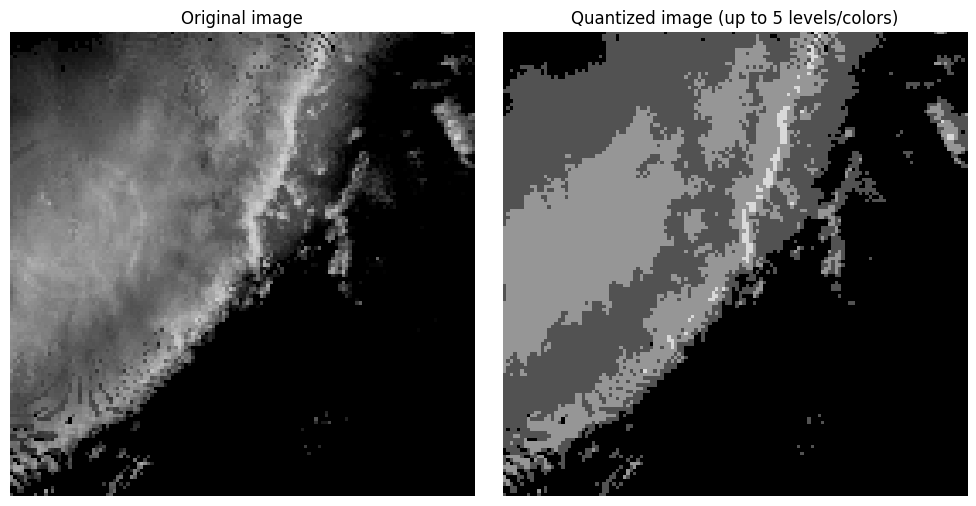

In [3]:
import numpy as np
import matplotlib.pyplot as plt

img = np.flipud(x_train[199,:,:,0])

# quantize by 20 dBZ up to 80 dBZ
img_quant = np.round(img / 20) * 20
img_quant = np.clip(img_quant, 0, 80)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="Grays_r", vmin=0, vmax=80)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_quant, cmap="Grays_r", vmin=0, vmax=80)
plt.title("Quantized image (up to 5 levels/colors)")
plt.axis("off")

plt.tight_layout()
plt.show()

Notice in the image above that you have large regions of that contain the same pixel value. This produces [color banding](https://en.wikipedia.org/wiki/Colour_banding) or [posterization](https://en.wikipedia.org/wiki/Posterization), where smooth gradients are replaced by abrupt step changes. This is typically an undesirable outcome of color quantization or compression that uses color quantization. [Dithering](https://en.wikipedia.org/wiki/Dither) can be used to break up the color banding and sometimes produce a more realistic looking image without increasing the number of colors. This is done by spreading (or diffusing) the quantization error (i.e., difference between the original and quantized pixel values) between a pixel and its neighbors. In the loop below, you can see that each pixel is visited once and the quantization error is calculated. That error is then added to neighboring pixel values using the [Floyd-Steinberg](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) approach that applies specific weights to the error added to neighbors in a moving window relative to each visited pixel. Spatial averaging gives the perception of intermediate tones. For example, the combination of black and dark grey pixels in a region gives the appearance of a color between black and dark grey without actually storing that color.

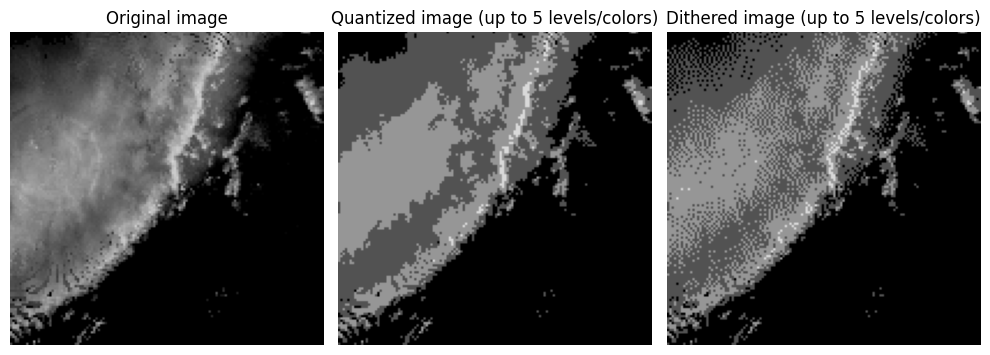

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Assume img is already defined and is a 2D grayscale image
# with values in the range 0 to 80

dithered = img.astype(float).copy()
rows, cols = dithered.shape

for y in range(rows):
    for x in range(cols):
        old_pixel = dithered[y, x]

        levels = np.array([0, 20, 40, 60, 80], dtype=float)
        new_pixel = levels[np.argmin(np.abs(levels - old_pixel))]
        dithered[y, x] = new_pixel

        error = old_pixel - new_pixel

        if x + 1 < cols:
            dithered[y, x + 1] += error * 7 / 16
        if y + 1 < rows and x - 1 >= 0:
            dithered[y + 1, x - 1] += error * 3 / 16
        if y + 1 < rows:
            dithered[y + 1, x] += error * 5 / 16
        if y + 1 < rows and x + 1 < cols:
            dithered[y + 1, x + 1] += error * 1 / 16

dithered = np.clip(dithered, 0, 80)

plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="Grays_r", vmin=0, vmax=80)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_quant, cmap="Grays_r", vmin=0, vmax=80)
plt.title("Quantized image (up to 5 levels/colors)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(dithered, cmap="Grays_r", vmin=0, vmax=80)
plt.title("Dithered image (up to 5 levels/colors)")
plt.axis("off")

plt.tight_layout()
plt.show()

### Chapter 9.6.2 - Encoding and Decoding

With the limitations of encoding and decoding in mind, we can simulate encoding and then decoding an image using downsampling and upsampling. We will apply an edge detection convolution followed by a max pooling to reduce the image dimensions to a representation and then recover the original dimensions.

First, define the max pooling function:

In [5]:
def max_pool_3x3(x):
    '''Transforms an image by turning each 3x3 pixel neighborhood
    into 1 pixel by calculating the maximum value in that neighborhood
    and placing it in the transformed image in the position representative
    of the original neighborhood's position.

    Parameters
    --------------------------
    x: numpy ndarray
        image to transform

    Returns
    --------------------------
    pooled: numpy ndarray
        transformed image
    '''
    h, w = x.shape

    out_h = h // 3
    out_w = w // 3

    pooled = np.zeros((out_h, out_w), dtype=float)

    for i in range(out_h):
        for j in range(out_w):
            neighborhood = x[i*3:i*3+3, j*3:j*3+3]

            # Problem 3
            pooled[i, j] = np.max(neighborhood)

    return pooled

Next, define the edge detection kernel:

In [6]:
edge_kernel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=float)

Define the "encoder" steps. We use "same" to make the encoding steps easier.

In [7]:
from scipy.signal import convolve2d

# crop to 135x135 to make it easier to do a 3x down/up sampling.
crop_img = img[:-1, :-1]

# Step 1
conv1 = convolve2d(img, edge_kernel, mode="same")
act1  = np.maximum(conv1, 0)
pool1 = max_pool_3x3(act1)
print("Size of pool1 is", pool1.shape)

# Step 2
conv2 = convolve2d(pool1, edge_kernel, mode="same")
act2  = np.maximum(conv2, 0)
pool2 = max_pool_3x3(act2)
print("Size of pool2 is", pool2.shape)

# Step 3
conv3 = convolve2d(pool2, edge_kernel, mode="same")
act3  = np.maximum(conv3, 0)
pool3 = max_pool_3x3(act3)
print("Size of pool3 is", pool3.shape)

Size of pool1 is (45, 45)
Size of pool2 is (15, 15)
Size of pool3 is (5, 5)


Visualize the encoder steps:

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

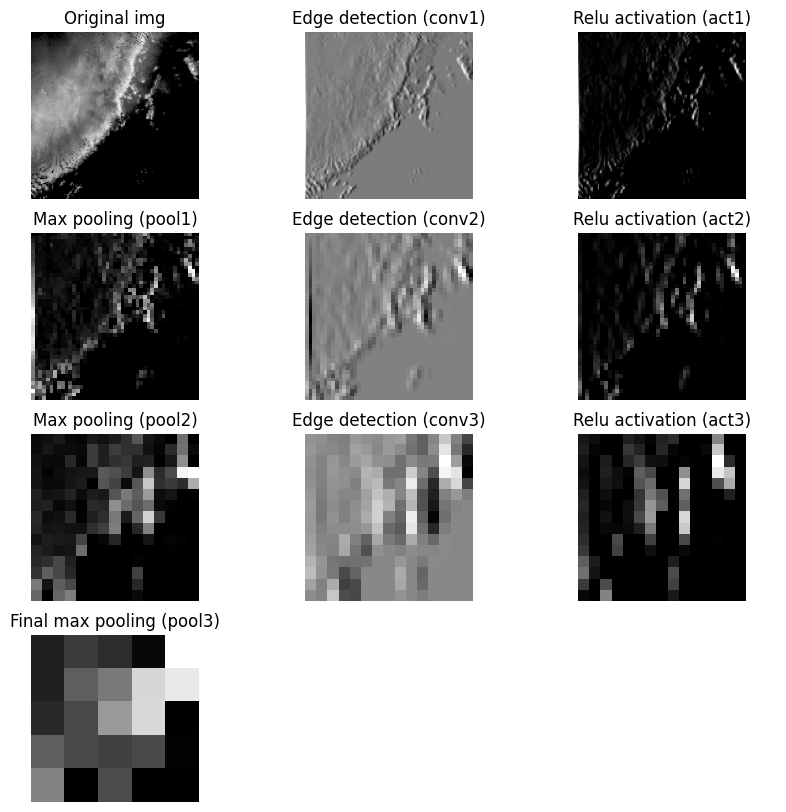

In [8]:
fig, ax = plt.subplots(4, 3, figsize=(10, 10))

ax[0, 0].imshow(img, cmap="gray")
ax[0, 0].set_title("Original img")
ax[0, 0].axis("off")

ax[0, 1].imshow(conv1, cmap="gray")
ax[0, 1].set_title("Edge detection (conv1)")
ax[0, 1].axis("off")

ax[0, 2].imshow(act1, cmap="gray")
ax[0, 2].set_title("Relu activation (act1)")
ax[0, 2].axis("off")

ax[1, 0].imshow(pool1, cmap="gray")
ax[1, 0].set_title("Max pooling (pool1)")
ax[1, 0].axis("off")

ax[1, 1].imshow(conv2, cmap="gray")
ax[1, 1].set_title("Edge detection (conv2)")
ax[1, 1].axis("off")

ax[1, 2].imshow(act2, cmap="gray")
ax[1, 2].set_title("Relu activation (act2)")
ax[1, 2].axis("off")

ax[2, 0].imshow(pool2, cmap="gray")
ax[2, 0].set_title("Max pooling (pool2)")
ax[2, 0].axis("off")

ax[2, 1].imshow(conv3, cmap="gray")
ax[2, 1].set_title("Edge detection (conv3)")
ax[2, 1].axis("off")

ax[2, 2].imshow(act3, cmap="gray")
ax[2, 2].set_title("Relu activation (act3)")
ax[2, 2].axis("off")

ax[3, 0].imshow(pool3, cmap="gray")
ax[3, 0].set_title("Final max pooling (pool3)")
ax[3, 0].axis("off")

ax[3, 1].axis("off")
ax[3, 2].axis("off")

**Decoder steps**

The decoder filter is a modified blur/smooth filter. Note that in a U-Net, this filter will be modified during the training process.

In [9]:
recon_kernel = np.array([[2, 4, 2],
                         [4, 8, 4],
                         [2, 4, 2]])

Define the unpool3x3 function. This function is the opposite of the max pooling step. However, since we lost most of the spatial data in each 3x3 neighborhood, the decoder step must fill in missing values using the filter above.

In [10]:
def unpool_3x3(x):
    out = np.zeros((x.shape[0] * 3, x.shape[1] * 3), dtype=float)
    out[::3, ::3] = x
    return out

Apply the same number of unpool steps as pooling steps to recover the original image dimensions:

In [11]:
upool1 = unpool_3x3(pool3)
dconv1 = convolve2d(upool1, recon_kernel, mode="same")
dact1 = np.maximum(dconv1, 0)
print("dact1 shape is", dact1.shape)

upool2 = unpool_3x3(dact1)
dconv2 = convolve2d(upool2, recon_kernel, mode="same")
dact2 = np.maximum(dconv2, 0)
print("dact2 shape is", dact2.shape)

upool3 = unpool_3x3(dact2)
dconv3 = convolve2d(upool3, recon_kernel, mode="same")
dact3 = np.maximum(dconv3, 0)
print("dact3 shape is", dact3.shape)

dact1 shape is (15, 15)
dact2 shape is (45, 45)
dact3 shape is (135, 135)


Visualize the decoder steps:

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

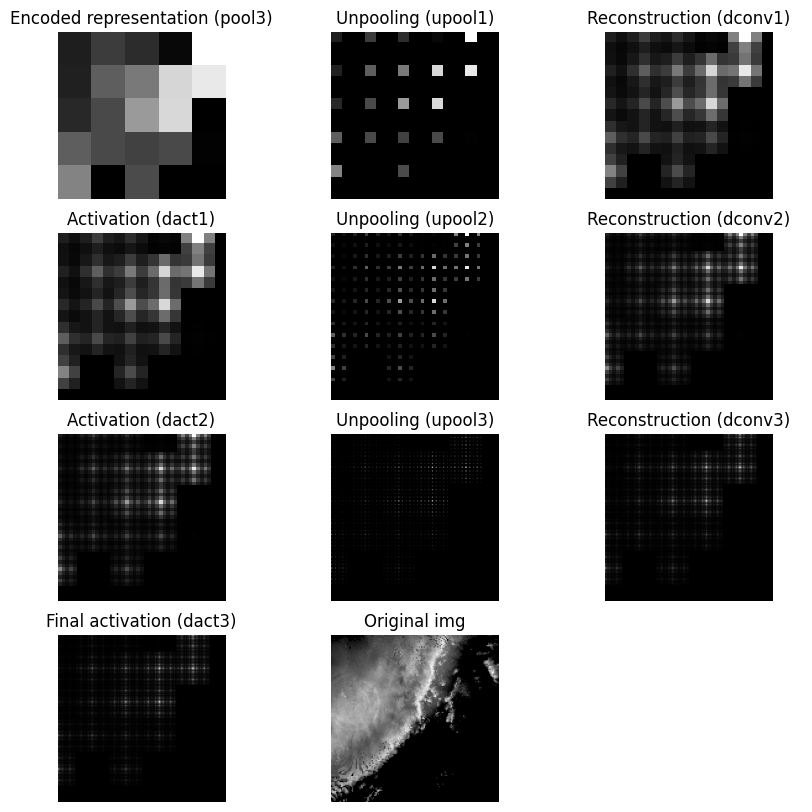

In [12]:
fig, ax = plt.subplots(4, 3, figsize=(10, 10))

ax[0, 0].imshow(pool3, cmap="gray")
ax[0, 0].set_title("Encoded representation (pool3)")
ax[0, 0].axis("off")

ax[0, 1].imshow(upool1, cmap="gray")
ax[0, 1].set_title("Unpooling (upool1)")
ax[0, 1].axis("off")

ax[0, 2].imshow(dconv1, cmap="gray")
ax[0, 2].set_title("Reconstruction (dconv1)")
ax[0, 2].axis("off")

ax[1, 0].imshow(dact1, cmap="gray")
ax[1, 0].set_title("Activation (dact1)")
ax[1, 0].axis("off")

ax[1, 1].imshow(upool2, cmap="gray")
ax[1, 1].set_title("Unpooling (upool2)")
ax[1, 1].axis("off")

ax[1, 2].imshow(dconv2, cmap="gray")
ax[1, 2].set_title("Reconstruction (dconv2)")
ax[1, 2].axis("off")

ax[2, 0].imshow(dact2, cmap="gray")
ax[2, 0].set_title("Activation (dact2)")
ax[2, 0].axis("off")

ax[2, 1].imshow(upool3, cmap="gray")
ax[2, 1].set_title("Unpooling (upool3)")
ax[2, 1].axis("off")

ax[2, 2].imshow(dconv3, cmap="gray")
ax[2, 2].set_title("Reconstruction (dconv3)")
ax[2, 2].axis("off")

ax[3, 0].imshow(dact3, cmap="gray")
ax[3, 0].set_title("Final activation (dact3)")
ax[3, 0].axis("off")

ax[3, 1].imshow(img, cmap="gray")
ax[3, 1].set_title("Original img")
ax[3, 1].axis("off")

ax[3, 2].axis("off")

It is difficult for the decoder to generate a smooth upsampled result when unpooling creates neighborhoods that are mostly zeros. That sparse structure can interact with the reconstruction convolution and lead to checkerboard artifacts. If this pattern appears in the output, the issue may come from the unpooling strategy rather than the original image content. One alternative is to replace zero-insertion unpooling with value replication, where each pooled value is repeated across the full neighborhood. This does not recover the original image, but it usually produces a smoother and more stable upsampling result.

The following code demonstrates value replication for the unpooling function. While neither of these toy examples completely describe the actual encoder-decoder model, it is a sufficient demonstration of the internal model steps.

dact1 shape is (15, 15)
dact2 shape is (45, 45)
dact3 shape is (135, 135)


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

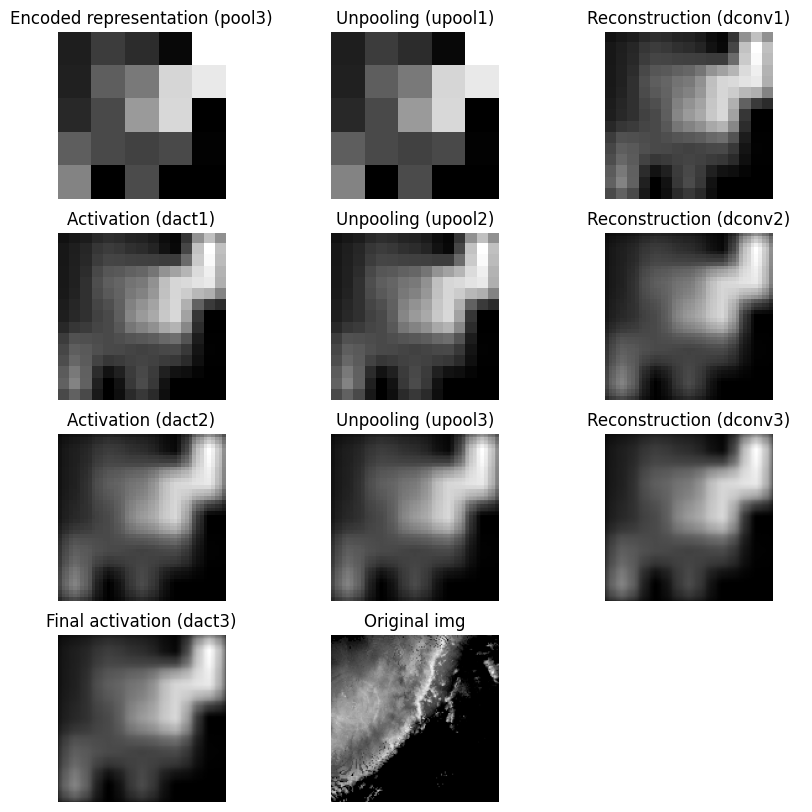

In [13]:
def unpool_3x3(x):
    return np.repeat(np.repeat(x, 3, axis=0), 3, axis=1)

upool1 = unpool_3x3(pool3)
dconv1 = convolve2d(upool1, recon_kernel, mode="same")
dact1 = np.maximum(dconv1, 0)
print("dact1 shape is", dact1.shape)

upool2 = unpool_3x3(dact1)
dconv2 = convolve2d(upool2, recon_kernel, mode="same")
dact2 = np.maximum(dconv2, 0)
print("dact2 shape is", dact2.shape)

upool3 = unpool_3x3(dact2)
dconv3 = convolve2d(upool3, recon_kernel, mode="same")
dact3 = np.maximum(dconv3, 0)
print("dact3 shape is", dact3.shape)

fig, ax = plt.subplots(4, 3, figsize=(10, 10))

ax[0, 0].imshow(pool3, cmap="gray")
ax[0, 0].set_title("Encoded representation (pool3)")
ax[0, 0].axis("off")

ax[0, 1].imshow(upool1, cmap="gray")
ax[0, 1].set_title("Unpooling (upool1)")
ax[0, 1].axis("off")

ax[0, 2].imshow(dconv1, cmap="gray")
ax[0, 2].set_title("Reconstruction (dconv1)")
ax[0, 2].axis("off")

ax[1, 0].imshow(dact1, cmap="gray")
ax[1, 0].set_title("Activation (dact1)")
ax[1, 0].axis("off")

ax[1, 1].imshow(upool2, cmap="gray")
ax[1, 1].set_title("Unpooling (upool2)")
ax[1, 1].axis("off")

ax[1, 2].imshow(dconv2, cmap="gray")
ax[1, 2].set_title("Reconstruction (dconv2)")
ax[1, 2].axis("off")

ax[2, 0].imshow(dact2, cmap="gray")
ax[2, 0].set_title("Activation (dact2)")
ax[2, 0].axis("off")

ax[2, 1].imshow(upool3, cmap="gray")
ax[2, 1].set_title("Unpooling (upool3)")
ax[2, 1].axis("off")

ax[2, 2].imshow(dconv3, cmap="gray")
ax[2, 2].set_title("Reconstruction (dconv3)")
ax[2, 2].axis("off")

ax[3, 0].imshow(dact3, cmap="gray")
ax[3, 0].set_title("Final activation (dact3)")
ax[3, 0].axis("off")

ax[3, 1].imshow(img, cmap="gray")
ax[3, 1].set_title("Original img")
ax[3, 1].axis("off")

ax[3, 2].axis("off")

### Chapter 9.6.3 - Measures of pixel-wise model performance.

Assessing how well a pixel-wise model is performing can be more complex than a CNN. For example, in a 136x136 image, a CNN provides 1 prediction. A U-Net provides 18,496 predictions. With sparse data (e.g., many zeros), this can result in extreme class imbalances.

For example, lets examine the following image. It depicts a region of high intensity pixels in the center of the image surrounded by pixels intensities of 0.

(np.float64(-0.5), np.float64(135.5), np.float64(135.5), np.float64(-0.5))

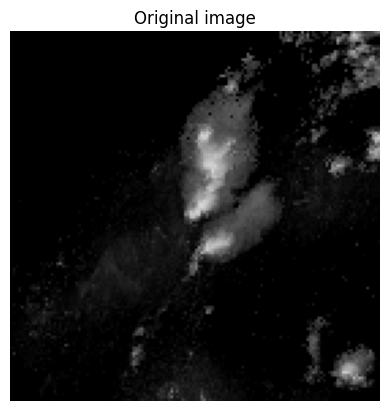

In [14]:
import numpy as np
import matplotlib.pyplot as plt

img = np.flipud(x_train[254,:,:,0])

plt.imshow(img, cmap="Grays_r", vmin=0, vmax=80)
plt.title("Original image")
plt.axis("off")

We can see how many times each pixel value shows up using the `return_counts` argument in `np.unique`. This shows us that there are over 11,000 pixels with a count of 0. This represents nearly 60% of the total pixels. In other words, a model predicting 0 for every pixel would get a passing grade!

In [15]:
np.unique(img, return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60], dtype=uint8),
 array([11062,   862,   904,   761,   667,   580,   397,   312,   228,
          201,   150,   154,   155,   152,   158,   145,   167,   148,
          131,   152,   144,    93,    66,    49,    42,    33,    39,
           26,    34,    24,    32,    19,    19,    23,    22,    18,
           17,    25,    26,    21,    19,    12,    17,    25,    23,
           19,    16,    15,    13,    12,    15,    12,     6,     4,
            6,     8,     7,     3,     3,     2,     1]))


One way to get a more realistic metric for pixel-wise predictions is to use [Intersection over Union](https://en.wikipedia.org/wiki/Jaccard_index)

$ IoU = TP / (TP + FP + FN) $

Just based on what we know about supervised machine learning, this metric appears to reward correctly identifying positive pixels while penalizing false alarms and misses. That is correct, but a bit more context is provided when you think of this from a pixel-wise perspective.

1. TP - pixel where both the target and prediction are equivalent. The total number of TPs represents the total area (i.e., total number of pixels) where the positive label was correctly predicted by the model.

2. FP - pixel where the target is a negative label but the prediction is positive label. The total area covered by FPs represents incorrect positive predictions.

3. FN - pixel where the target is a positive label but the prediction is a negative label. The total area covered by FNs represents incorrect negative predictions.

In other words, if we want to maximize our IoU score, we need to correctly predict as many positive pixels as possible while minimizing misses (FN) and false alarms (FP). Interestingly, this metric is equivalent to Critical Success Index (CSI) that is often used to examine weather forecast quality. Tornado warnings, for example, are of high quality if most of your warnings over several years contain a confirmed tornado (TP), few do not contain a confirmed tornado (FP), *and* you do not miss many tornadoes (FN). This makes sure that residents are confident in your warnings.

In a very simple example, say we want the model to accurately predict where 40 dBZ or greater pixels are occuring. We would set these pixels to 1 and all other pixels to 0. I will just offset a "prediction" by 20 pixels in the y-dimension.

If we took the accuracy of this method, we would get a very high score.

total pixel count 18496
total correct predictions 18125
Accuracy 97.99416089965398


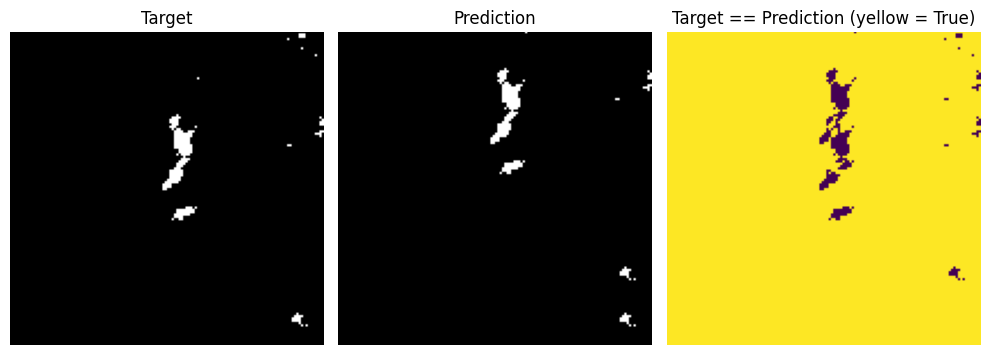

In [16]:
target = 1*(img >= 40)

prediction = target.copy()
prediction[:-20] = prediction[20:]

plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(target, cmap="Grays_r", vmin=0, vmax=1)
plt.title("Target")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(prediction, cmap="Grays_r", vmin=0, vmax=1)
plt.title("Prediction")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(target == prediction, cmap="viridis", vmin=0, vmax=1)
plt.title("Target == Prediction (yellow = True)")
plt.axis("off")

plt.tight_layout()

print("total pixel count", target.shape[0] * target.shape[1])
print("total correct predictions", np.sum(target==prediction))
print("Accuracy", 100 * np.sum(target==prediction) / (target.shape[0] * target.shape[1]))

If we instead calculated the IoU score (also called `Jaccard score` in packages like sklearn) we would see that without the large number of true negatives, the pixel-wise performance of the model is relatively low.

In [17]:
from sklearn.metrics import jaccard_score

TP = np.sum((target == 1) & (prediction == 1))
FP = np.sum((target == 0) & (prediction == 1))
FN = np.sum((target == 1) & (prediction == 0))

IoU = TP / (TP + FP + FN)

print("IoU score is", IoU)

iou = jaccard_score(target.ravel(), prediction.ravel(), average="binary")
print("sklearn jaccard score is", iou)

IoU score is 0.13114754098360656
sklearn jaccard score is 0.13114754098360656


In the chart below, the spatial offset of the simulated prediction is increased by 1 pixel. Notice a steep drop off in IoU as the predicted cell gets farther away from the target cell.

sklearn jaccard score is 0.5761589403973509 with offset 1
sklearn jaccard score is 0.4161676646706587 with offset 2
sklearn jaccard score is 0.3165266106442577 with offset 3
sklearn jaccard score is 0.25066666666666665 with offset 4
sklearn jaccard score is 0.21502590673575128 with offset 5
sklearn jaccard score is 0.181360201511335 with offset 6
sklearn jaccard score is 0.14950980392156862 with offset 7
sklearn jaccard score is 0.125 with offset 8
sklearn jaccard score is 0.11374407582938388 with offset 9
sklearn jaccard score is 0.1056338028169014 with offset 10
sklearn jaccard score is 0.10747663551401869 with offset 11
sklearn jaccard score is 0.11421911421911422 with offset 12
sklearn jaccard score is 0.11832946635730858 with offset 13
sklearn jaccard score is 0.12325581395348838 with offset 14
sklearn jaccard score is 0.13114754098360656 with offset 15
sklearn jaccard score is 0.12850467289719625 with offset 16
sklearn jaccard score is 0.12850467289719625 with offset 17
sklearn j

Text(0.5, 0, 'Offset in y dim')

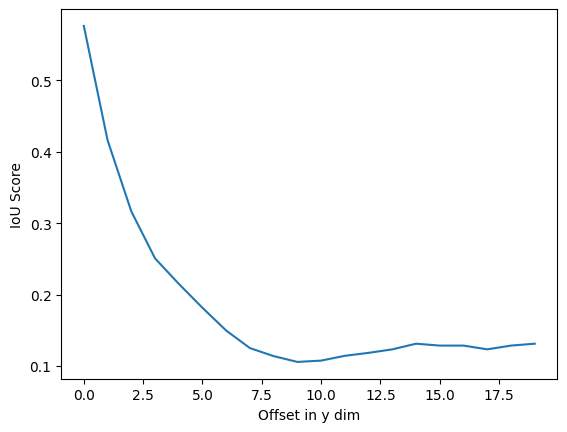

In [18]:
target = 1*(img >= 40)

iou_vals = []

for offset in range(1, 21):
    prediction = target.copy()
    prediction[:-offset] = prediction[offset:]

    iou = jaccard_score(target.ravel(), prediction.ravel(), average="binary")
    print("sklearn jaccard score is", iou, "with offset", offset)

    iou_vals.append(iou)

plt.plot(iou_vals)
plt.ylabel("IoU Score")
plt.xlabel("Offset in y dim")